In [1]:
# Manipulação, plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from sklearn.model_selection import train_test_split
from scipy.special import erfcx
import pywt

# Rede neural
import torch
import torch.nn as nn

np.random.seed(99)

In [15]:
df = pd.read_csv('model_input.csv')
df.head(8)

,Echo_Bin_1,Echo_Bin_2,Echo_Bin_3,Echo_Bin_4,Echo_Bin_5,Echo_Bin_6,Echo_Bin_7,Echo_Bin_8,Echo_Bin_9,Echo_Bin_10,...,Echo_Bin_495,Echo_Bin_496,Echo_Bin_497,Echo_Bin_498,Echo_Bin_499,Echo_Bin_500,Swirr_PHIX,MBVI,MPHI,PHIX
0,0.992462,0.970283,0.944387,0.915175,0.883944,0.851469,0.818344,0.785210,0.752143,0.719919,...,0.014375,0.012839,0.011605,0.010724,0.010185,0.009978,0.656594,0.244925,0.309553,0.373023
1,0.993006,0.972291,0.947881,0.920159,0.890408,0.859388,0.827657,0.795852,0.764068,0.733073,...,0.005944,0.005813,0.005884,0.006180,0.006679,0.007369,0.705920,0.251558,0.324391,0.356355
2,0.993040,0.972478,0.948335,0.920989,0.891687,0.861172,0.829993,0.798772,0.767603,0.737238,...,0.007235,0.007784,0.008428,0.009170,0.010028,0.010979,0.743156,0.258190,0.339230,0.347424
3,0.992911,0.972098,0.947871,0.920604,0.891483,0.861221,0.830372,0.799523,0.768733,0.738715,...,0.013997,0.014149,0.014261,0.014326,0.014370,0.014391,0.677602,0.236270,0.327660,0.348686
4,0.993487,0.974376,0.952146,0.927128,0.900384,0.872551,0.844126,0.815626,0.787095,0.759163,...,0.002532,0.002638,0.002936,0.003456,0.004269,0.005323,0.621254,0.221170,0.313470,0.356006
5,0.993704,0.975177,0.953539,0.929111,0.902945,0.875667,0.847752,0.819715,0.791609,0.764059,...,0.019026,0.018371,0.017815,0.017377,0.017058,0.016854,0.621680,0.220865,0.308485,0.355271
6,0.993472,0.974259,0.951815,0.926481,0.899365,0.871130,0.842278,0.813356,0.784423,0.756142,...,0.035243,0.035388,0.035216,0.034688,0.033856,0.032734,0.595423,0.220560,0.303500,0.370426
7,0.993148,0.973003,0.949503,0.923008,0.894680,0.865213,0.835142,0.805038,0.774963,0.745609,...,0.030123,0.029720,0.029100,0.028237,0.027145,0.025848,0.632072,0.230720,0.298680,0.365022


In [18]:
colunas_num = df[['Swirr_PHIX','MBVI','MPHI','PHIX']]

,Swirr_PHIX,MBVI,MPHI,PHIX
0,0.656594,0.244925,0.309553,0.373023
1,0.705920,0.251558,0.324391,0.356355
2,0.743156,0.258190,0.339230,0.347424
3,0.677602,0.236270,0.327660,0.348686
4,0.621254,0.221170,0.313470,0.356006
...,...,...,...,...
570,0.455738,0.166560,0.265820,0.365474
571,0.603281,0.204060,0.318200,0.338250
572,0.761814,0.255830,0.406020,0.335817
573,0.823391,0.276590,0.439990,0.335916


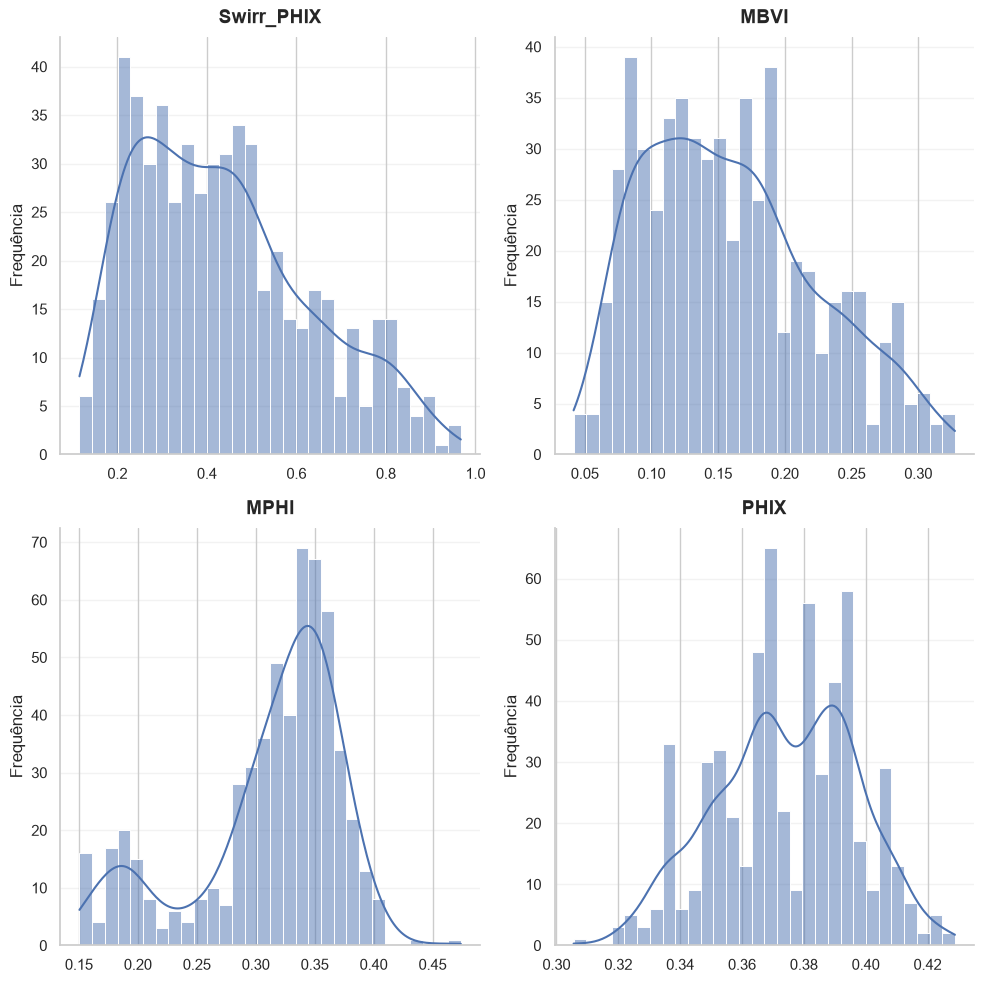

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

colunas_num = df[['Swirr_PHIX', 'MBVI', 'MPHI', 'PHIX']]

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 10)
)

axes = axes.flatten()

for ax, coluna in zip(axes, colunas_num.columns):
    sns.histplot(
        data=colunas_num,
        x=coluna,
        bins=30,
        kde=True,
        ax=ax,
        edgecolor="white",
        linewidth=0.7
    )

    ax.set_title(coluna, fontsize=14, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Frequência")
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)

plt.savefig(
    "distribuicao_variaveis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [7]:
train_df, test_df = train_test_split(df, test_size=175, random_state=42)

print(f"Shape original do Treino: {train_df.shape}")
print(f"Shape do Teste (Intocado): {test_df.shape}")

Shape original do Treino: (400, 504)
Shape do Teste (Intocado): (175, 504)


In [8]:
# DATA AUGMENTATION (MixUp)
#gerar 1600 sintéticos.
n_sinteticos = 1000 - len(train_df)

# Nomes das colunas de ecos (as primeiras 500) e os targets
echo_cols = train_df.columns[:-4]

# Arrays para armazenar os novos dados
novos_registros = []

In [9]:
for _ in range(n_sinteticos):
    # Sorteia duas amostras aleatórias do conjunto de TREINO
    idx1, idx2 = np.random.choice(train_df.index, size=2, replace=False)
    amostra1 = train_df.loc[idx1]
    amostra2 = train_df.loc[idx2]
    
    # Sorteia um peso w entre 0 e 1
    w = np.random.rand()
    
    # 1. Interpolação dos Ecos (Sinal de RMN)
    m_syn = w * amostra1[echo_cols] + (1 - w) * amostra2[echo_cols]
    
    # 2. Interpolação das propriedades físicas
    # Denominador (Porosidade mista)
    phi_syn = w * amostra1['PHIX'] + (1 - w) * amostra2['PHIX']
    mphi_syn = w * amostra1['MPHI'] + (1 - w) * amostra2['MPHI']
    
    # Numerador (Volume Irredutível misto)
    mbvi_syn = w * amostra1['MBVI'] + (1 - w) * amostra2['MBVI']
    
    # 3. Cálculo da Saturação Sintética (Equação do artigo)
    swirr_syn = mbvi_syn / phi_syn
    
    # Monta a nova linha combinando o sinal e os targets
    novo_registro = m_syn.to_dict()
    novo_registro.update({
        'Swirr_PHIX': swirr_syn,
        'MBVI': mbvi_syn,
        'MPHI': mphi_syn,
        'PHIX': phi_syn
    })
    
    novos_registros.append(novo_registro)

# Converte os registros sintéticos em DataFrame e junta ao treino original
df_sintetico = pd.DataFrame(novos_registros)
train_df_augmented = pd.concat([train_df, df_sintetico], ignore_index=True)

# Embaralha (shuffle) o novo dataset de treino para misturar reais e sintéticos
train_df_augmented = train_df_augmented.sample(frac=1.0, random_state=42).reset_index(drop=True)

print(f"Novo shape do Treino Aumentado: {train_df_augmented.shape}")

Novo shape do Treino Aumentado: (1000, 504)


In [11]:
train_df_augmented

,Echo_Bin_1,Echo_Bin_2,Echo_Bin_3,Echo_Bin_4,Echo_Bin_5,Echo_Bin_6,Echo_Bin_7,Echo_Bin_8,Echo_Bin_9,Echo_Bin_10,...,Echo_Bin_495,Echo_Bin_496,Echo_Bin_497,Echo_Bin_498,Echo_Bin_499,Echo_Bin_500,Swirr_PHIX,MBVI,MPHI,PHIX
0,0.995036,0.980400,0.963263,0.943890,0.923145,0.901544,0.879480,0.857377,0.835283,0.813713,...,0.033869,0.033726,0.033702,0.033808,0.034044,0.034396,0.427421,0.163568,0.380695,0.382685
1,0.993749,0.975369,0.953924,0.929740,0.903861,0.876914,0.849378,0.821767,0.794129,0.767086,...,0.033254,0.033176,0.033013,0.032754,0.032399,0.031959,0.476737,0.176525,0.285951,0.370278
2,0.995048,0.980467,0.963427,0.944186,0.923590,0.902143,0.880226,0.858257,0.836287,0.814824,...,0.027579,0.027552,0.027486,0.027375,0.027249,0.027104,0.408896,0.155584,0.347952,0.380497
3,0.994728,0.979199,0.961038,0.940515,0.918530,0.895615,0.872168,0.848633,0.825074,0.802029,...,0.047585,0.048157,0.048471,0.048495,0.048268,0.047799,0.369244,0.144167,0.316960,0.390438
4,0.993171,0.973068,0.949580,0.923062,0.894667,0.865085,0.834843,0.804504,0.774126,0.744392,...,0.033411,0.033652,0.033561,0.033097,0.032271,0.031114,0.601241,0.211527,0.274607,0.351817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.996311,0.985463,0.972806,0.958518,0.943201,0.927207,0.910801,0.894275,0.877671,0.861345,...,0.051479,0.051513,0.051919,0.052742,0.053957,0.055524,0.290779,0.117585,0.361220,0.404379
996,0.993487,0.974376,0.952146,0.927128,0.900384,0.872551,0.844126,0.815626,0.787095,0.759163,...,0.002532,0.002638,0.002936,0.003456,0.004269,0.005323,0.621254,0.221170,0.313470,0.356006
997,0.991891,0.967945,0.939843,0.908038,0.873988,0.838566,0.802435,0.766316,0.730300,0.695265,...,0.025094,0.025134,0.025306,0.025619,0.025970,0.026383,0.852482,0.290669,0.312561,0.340968
998,0.995469,0.982095,0.966412,0.948653,0.929598,0.909709,0.889324,0.868831,0.848289,0.828169,...,0.027100,0.026914,0.026688,0.026413,0.026059,0.025641,0.341111,0.121229,0.322167,0.355394


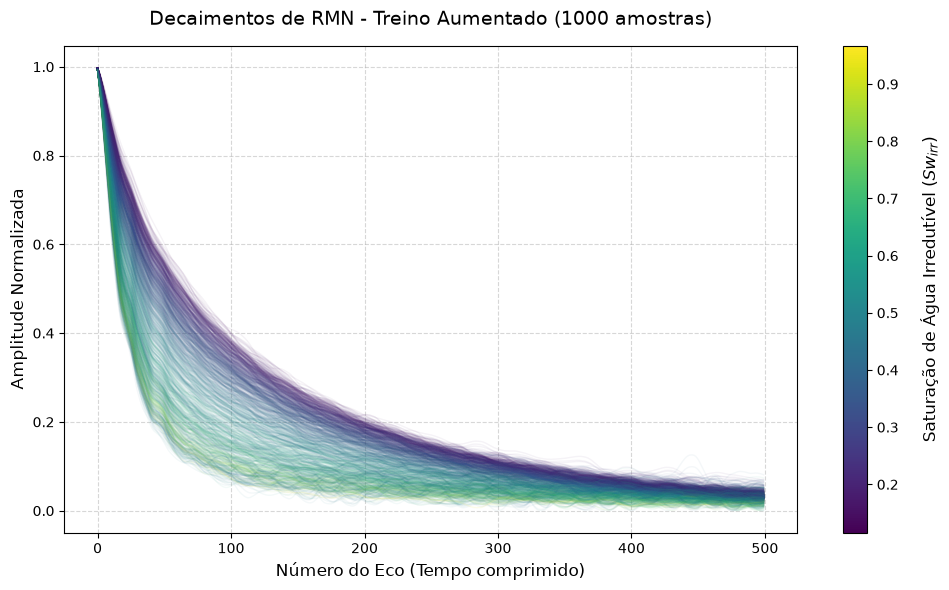

In [10]:
# 1. Separando X (ecos) e y (Swirr) a partir do dataframe aumentado
X_train_plot = train_df_augmented.iloc[:, :-4] # Pega todas as colunas exceto as 4 últimas
y_train_plot = train_df_augmented['Swirr_PHIX']

plt.figure(figsize=(10, 6))
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=y_train_plot.min(), vmax=y_train_plot.max())

# 3. Loop de plotagem das 2000 curvas
for idx in train_df_augmented.index:
    target_value = y_train_plot.loc[idx]
    color = cmap(norm(target_value))
    plt.plot(X_train_plot.loc[idx].values, color=color, alpha=0.05, linewidth=1)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Saturação de Água Irredutível ($Sw_{irr}$)', fontsize=12, labelpad=15)
plt.title('Decaimentos de RMN - Treino Aumentado (1000 amostras)', fontsize=14, pad=15)
plt.xlabel('Número do Eco (Tempo comprimido)', fontsize=12)
plt.ylabel('Amplitude Normalizada', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Redução das componentes: 

In [11]:
# 1. Separar as features (ecos) do dataframe de treino aumentado
X_train_pca = train_df_augmented.iloc[:, :-4]
y_train_pca = train_df_augmented['Swirr_PHIX']

# 2. Instanciar e ajustar o PCA
pca = PCA(n_components=0.999)
X_pca_transformed = pca.fit_transform(X_train_pca)

print(f"Shape original das features: {X_train_pca.shape}")
print(f"Novo shape após o PCA: {X_pca_transformed.shape}")
print(f"Número de componentes retidos: {pca.n_components_}")

Shape original das features: (1000, 500)
Novo shape após o PCA: (1000, 26)
Número de componentes retidos: 26


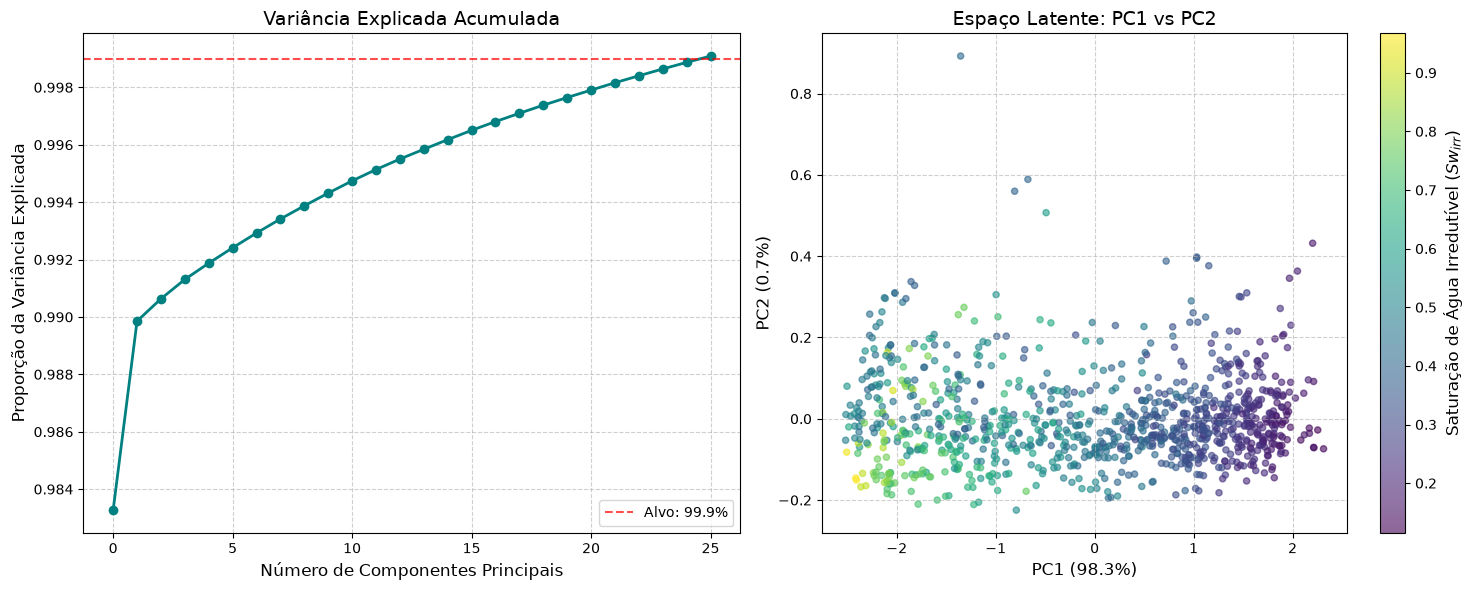

In [12]:
# 3. Visualização dos Resultados do PCA
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Variância Explicada Acumulada
axes[0].plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-', color='teal', linewidth=2)
axes[0].axhline(y=0.999, color='red', linestyle='--', alpha=0.7, label='Alvo: 99.9%')
axes[0].set_title('Variância Explicada Acumulada', fontsize=14)
axes[0].set_xlabel('Número de Componentes Principais', fontsize=12)
axes[0].set_ylabel('Proporção da Variância Explicada', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: PC1 vs PC2 coloridos pelo Alvo (Swirr)
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=y_train_pca.min(), vmax=y_train_pca.max())

scatter = axes[1].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], 
                          c=y_train_pca, cmap=cmap, norm=norm, alpha=0.6, s=20)

cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Saturação de Água Irredutível ($Sw_{irr}$)', fontsize=12)

axes[1].set_title('Espaço Latente: PC1 vs PC2', fontsize=14)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## MLP

Device is cpu


C:\Users\aryck\AppData\Local\Temp\ipykernel_20832\1175455854.py:25: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  X = torch.Tensor(train_df_pca.iloc[:,:-1].values).to(device)


Epoch 05 | Train MSE: 0.021857 | Val MSE: 0.014060
Epoch 10 | Train MSE: 0.010005 | Val MSE: 0.006531
Epoch 15 | Train MSE: 0.007652 | Val MSE: 0.005635
Epoch 20 | Train MSE: 0.006801 | Val MSE: 0.005130
Epoch 25 | Train MSE: 0.006311 | Val MSE: 0.004984
Epoch 30 | Train MSE: 0.006041 | Val MSE: 0.004821
Epoch 35 | Train MSE: 0.005924 | Val MSE: 0.004582
Epoch 40 | Train MSE: 0.005392 | Val MSE: 0.004546


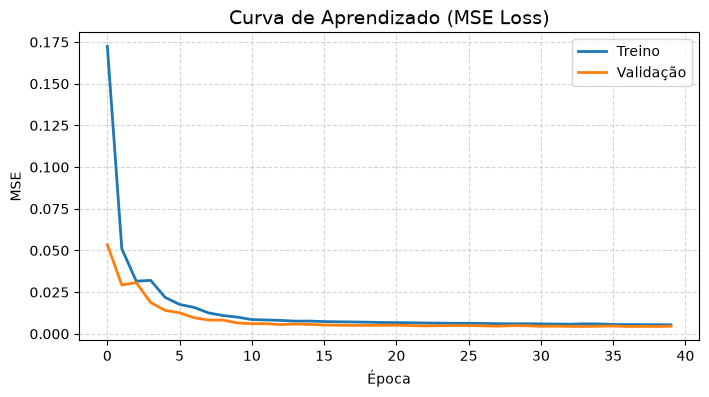


--- Métricas de Validação ---
RMSE: 0.0674
MAE:  0.0447
R²:   0.8190


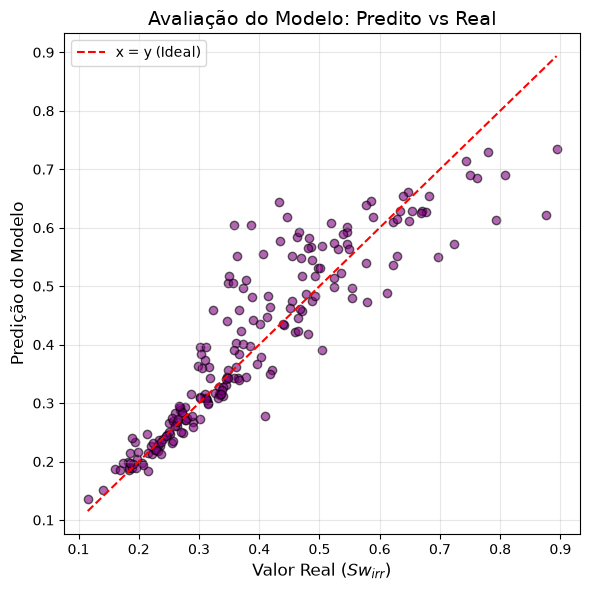

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Subset

# 1. Preparando o DataFrame do PCA
# Assumindo que X_pca_transformed (26 comp) e y_train_pca já existem da etapa anterior
train_df_pca = pd.DataFrame(X_pca_transformed)
train_df_pca['Swirr_PHIX'] = y_train_pca.values # Ajuste: Usando o nome correto do target

# 2. Divisão de Treino/Validação interna (80/20)
n = len(train_df_pca)
n_train = int(0.8 * n)

indices = np.arange(n)
np.random.seed(42) # AJUSTE: Semente para reprodutibilidade
np.random.shuffle(indices)

indx_train = indices[:n_train]
indx_val   = indices[n_train:]

# 3. Setup de Hardware e Tensores
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(train_df_pca.iloc[:,:-1].values).to(device)
y = torch.Tensor(train_df_pca['Swirr_PHIX'].values.reshape(-1,1)).to(device) # Ajuste: Nome correto

dataset = TensorDataset(X, y)
trainDs = Subset(dataset, indx_train)
valDs   = Subset(dataset, indx_val)

val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)

# 4. Construção do Modelo (MLP)
model = nn.Sequential(
    nn.Linear(X.shape[1], 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
    # AJUSTE: nn.Sigmoid() REMOVIDO para evitar limitação do range da predição em regressão
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 5. Loop de Treinamento
epochs = 40
history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
            
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if (epoch + 1) % 5 == 0: 
        print(f"Epoch {epoch + 1:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")

# 6. Gráfico de Histórico de Erro
plt.figure(figsize=(8, 4))
plt.plot(range(len(history)), [l[0] for l in history], label='Treino', linewidth=2)
plt.plot(range(len(history)), [l[1] for l in history], label='Validação', linewidth=2)
plt.title('Curva de Aprendizado (MSE Loss)', fontsize=14)
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 7. Avaliação e Métricas (AJUSTES DE VARIÁVEIS APLICADOS AQUI)
Xval = valDs.dataset.tensors[0][valDs.indices]
yval_MLP = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# Cálculo de RMSE, R2, MAE
mse = np.mean((y_pred - yval_MLP)**2)
mae = np.mean(np.abs((y_pred - yval_MLP)))
R2  = 1 - (mse / np.var(yval_MLP)) # AJUSTE: variância (std**2) corrigida para np.var

print(f"\n--- Métricas de Validação ---")
print(f"RMSE: {np.sqrt(mse):.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {R2:.4f}")

# Gráfico de Predito vs Real
plt.figure(figsize=(6, 6))
plt.scatter(yval_MLP, y_pred, alpha=0.6, color='purple', edgecolor='k') # AJUSTE: usando yval_MLP

# Reta ideal
min_val = min(y_pred.min(), yval_MLP.min())
max_val = max(y_pred.max(), yval_MLP.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='x = y (Ideal)')

plt.xlabel("Valor Real ($Sw_{irr}$)", fontsize=12)
plt.ylabel("Predição do Modelo", fontsize=12)
plt.title("Avaliação do Modelo: Predito vs Real", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PINN

O método inspirado em física se baseia em uma função bi-exponencial de forma
$$f(t) = A_o e^{-t/T_{2,o}} + A_w e^{-t/T_{2,w}} . $$
A rede neural tem como saída 4 parâmetros, para poder representar os 4 parâmetros da função acima, $A_o$ $A_w$ $T_{2,o}$ $T_{2,w}$ ($o$ para óleo, $w$ para água). A função de erro tem duas contribuições: uma é o fator $A_o/(A_o+A_w)$, a ser comparado com o output $y$ tradicional (erro de output); a outra utiliza os quatro parâmetros para reconstruir a função $f(t)$ acima, e a compara com a curva de entrada do modelo, $x$ (erro de fit).

Device is cpu
Epoch 010 | Train Out MSE: 0.0195 | Train Phys MSE: 0.0546 | Val Out MSE: 0.0146 | Val Phys MSE: 0.0573
Epoch 020 | Train Out MSE: 0.0130 | Train Phys MSE: 0.0170 | Val Out MSE: 0.0089 | Val Phys MSE: 0.0160
Epoch 030 | Train Out MSE: 0.0112 | Train Phys MSE: 0.0034 | Val Out MSE: 0.0068 | Val Phys MSE: 0.0033
Epoch 040 | Train Out MSE: 0.0093 | Train Phys MSE: 0.0021 | Val Out MSE: 0.0065 | Val Phys MSE: 0.0020
Epoch 050 | Train Out MSE: 0.0086 | Train Phys MSE: 0.0017 | Val Out MSE: 0.0064 | Val Phys MSE: 0.0017
Epoch 060 | Train Out MSE: 0.0088 | Train Phys MSE: 0.0016 | Val Out MSE: 0.0090 | Val Phys MSE: 0.0016
Epoch 070 | Train Out MSE: 0.0087 | Train Phys MSE: 0.0014 | Val Out MSE: 0.0062 | Val Phys MSE: 0.0014
Epoch 080 | Train Out MSE: 0.0089 | Train Phys MSE: 0.0014 | Val Out MSE: 0.0086 | Val Phys MSE: 0.0013
Epoch 090 | Train Out MSE: 0.0087 | Train Phys MSE: 0.0012 | Val Out MSE: 0.0065 | Val Phys MSE: 0.0011
Epoch 100 | Train Out MSE: 0.0089 | Train Phys MSE

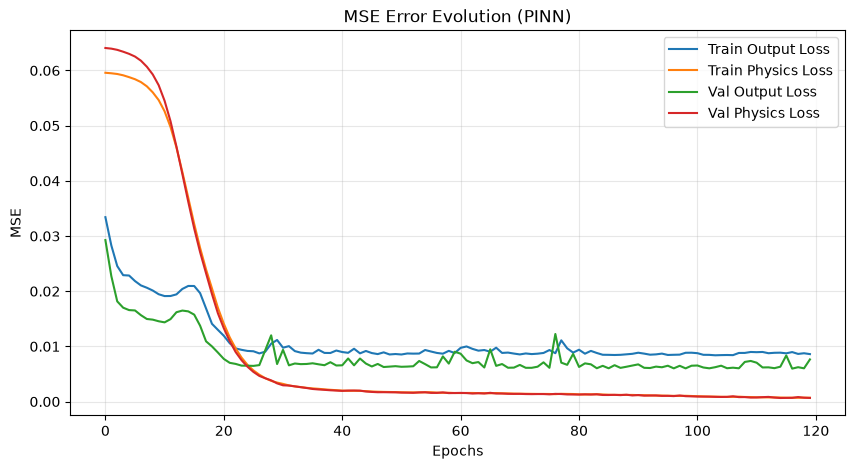

RMSE: 0.0874 | R²: 0.6959


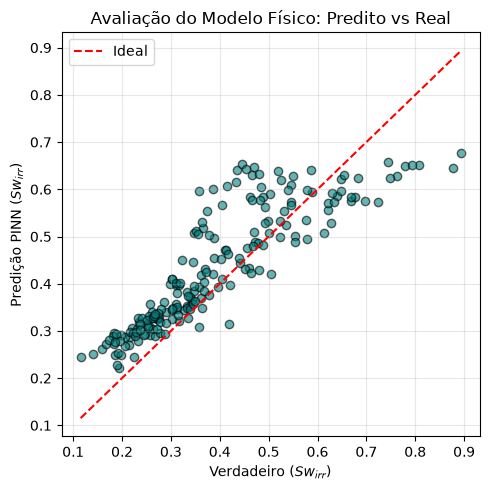

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARAÇÃO DOS DADOS (SEM PCA!)
# ==========================================
# Usaremos o dataset aumentado com os 500 ecos, ignorando as colunas físicas extra do final
# train_df_augmented tem 504 colunas: 500 ecos + Swirr_PHIX + MBVI + MPHI + PHIX
X_data = train_df_augmented.iloc[:, :500].values
y_data = train_df_augmented['Swirr_PHIX'].values.reshape(-1, 1)

n = len(X_data)
n_train = int(0.8 * n)

indices = np.arange(n)
np.random.seed(42) # Para reprodutibilidade
np.random.shuffle(indices)

indx_train = indices[:n_train]
indx_val   = indices[n_train:]

# Setup de device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

# Conversão para Tensores PyTorch
X = torch.Tensor(X_data).to(device)
y = torch.Tensor(y_data).to(device)

dataset = TensorDataset(X, y)
trainDs = Subset(dataset, indx_train)
valDs   = Subset(dataset, indx_val)

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

# ==========================================
# 2. DEFINIÇÃO DO MODELO PINN
# ==========================================
headlessmodel = nn.Sequential(
    nn.Linear(X.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 32),
    nn.ReLU(),
    nn.Linear(32, 4), # Saídas interpretadas como: A_o, A_w, T2_o, T2_w
).to(device)

optimizer = torch.optim.Adam(headlessmodel.parameters(), lr=1e-3)

# ==========================================
# 3. LOOP DE TREINAMENTO
# ==========================================
epochs = 120
history = []

for epoch in range(epochs):
    headlessmodel.train()
    train_loss_output, train_loss_phys = 0., 0.

    for xb, yb in train_loader:
        pre_outcome = headlessmodel(xb)
        
        # Funções de ativação para respeitar a física dos parâmetros
        outp1 = nn.Sigmoid()(pre_outcome[:,:2]) # Amplitudes (A_o, A_w) normalizadas entre 0 e 1
        outp2 = nn.functional.softplus(pre_outcome[:,2:]) # Tempos de relaxação (T2) devem ser estritamente positivos
        
        outcome = torch.cat([outp1, outp2], dim=1)
        outcome_ext = outcome.unsqueeze(1).expand(*xb.shape, outcome.shape[-1])
        
        # Vetor de tempo (índices dos 500 ecos)
        t_values = torch.arange(0, xb.shape[1]).unsqueeze(0).expand(xb.shape).to(device)
        
        # Loss 1: Erro da Saturação (A_o / (A_o + A_w))
        loss_output = nn.MSELoss()(outcome[:,0] / (outcome[:,0] + outcome[:,1] + 1e-8), yb.squeeze())
        
        # Loss 2: Erro de Reconstrução Física do Sinal RMN
        reconstrucao = (
            outcome_ext[:,:,0] * torch.exp(-t_values / torch.clamp(outcome_ext[:,:,2], min=1e-3)) + \
            outcome_ext[:,:,1] * torch.exp(-t_values / torch.clamp(outcome_ext[:,:,3], min=1e-3))
        )
        loss_phys = nn.MSELoss()(xb, reconstrucao) 

        optimizer.zero_grad()
        (loss_output + 4 * loss_phys).backward() # O fator 4 dá mais peso para a física
        optimizer.step()

        train_loss_output += loss_output.item() * xb.size(0)
        train_loss_phys += loss_phys.item() * xb.size(0)
        
    train_loss_output /= len(train_loader.dataset)
    train_loss_phys /= len(train_loader.dataset)

    # Avaliação
    headlessmodel.eval()
    val_loss_output, val_loss_phys = 0., 0.
    
    with torch.no_grad():
        for xb, yb in val_loader:
            pre_outcome = headlessmodel(xb)
            outp1 = nn.Sigmoid()(pre_outcome[:,:2])
            outp2 = nn.functional.softplus(pre_outcome[:,2:])
            outcome = torch.cat([outp1, outp2], dim=1)
            outcome_ext = outcome.unsqueeze(1).expand(*xb.shape, outcome.shape[-1])

            t_values = torch.arange(0, xb.shape[1]).unsqueeze(0).expand(xb.shape).to(device)
            
            loss_output = nn.MSELoss()(outcome[:,0] / (outcome[:,0] + outcome[:,1] + 1e-8), yb.squeeze())
            
            reconstrucao = (
                outcome_ext[:,:,0] * torch.exp(-t_values / torch.clamp(outcome_ext[:,:,2], min=1e-3)) + \
                outcome_ext[:,:,1] * torch.exp(-t_values / torch.clamp(outcome_ext[:,:,3], min=1e-3))
            )
            loss_phys = nn.MSELoss()(xb, reconstrucao)
                                          
            val_loss_output += loss_output.item() * xb.size(0)
            val_loss_phys += loss_phys.item() * xb.size(0)
            
        val_loss_output /= len(val_loader.dataset)
        val_loss_phys /= len(val_loader.dataset)

    history.append((train_loss_output, train_loss_phys, val_loss_output, val_loss_phys))

    if (epoch + 1) % 10 == 0: 
        print(f"Epoch {epoch + 1:03d} | Train Out MSE: {train_loss_output:.4f} | Train Phys MSE: {train_loss_phys:.4f} "
              f"| Val Out MSE: {val_loss_output:.4f} | Val Phys MSE: {val_loss_phys:.4f}")

# ==========================================
# 4. GRÁFICOS DE TREINAMENTO
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(range(len(history)), [l[0] for l in history], label='Train Output Loss')
plt.plot(range(len(history)), [l[1] for l in history], label='Train Physics Loss')
plt.plot(range(len(history)), [l[2] for l in history], label='Val Output Loss')
plt.plot(range(len(history)), [l[3] for l in history], label='Val Physics Loss')
plt.title('MSE Error Evolution (PINN)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 5. AVALIAÇÃO FINAL
# ==========================================
Xval = valDs.dataset.tensors[0][valDs.indices]
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

headlessmodel.eval()
with torch.no_grad():
    pre_outcome_val = headlessmodel(Xval)
    outp1_val = nn.Sigmoid()(pre_outcome_val[:,:2])
    outp2_val = nn.functional.softplus(pre_outcome_val[:,2:])
    y_param_pred = torch.cat([outp1_val, outp2_val], dim=1).squeeze().detach().cpu().numpy()
 
# Saturação é A_o / (A_o + A_w). Adicionando 1e-8 para evitar divisão por zero.
y_predPINN = y_param_pred[:,0] / (y_param_pred[:,0] + y_param_pred[:,1] + 1e-8)

# Métricas: RMSE, R2
mse = np.mean((y_predPINN - yval)**2)
R2  = 1 - (mse / np.var(yval)) # Correção: Usando np.var() ao invés de np.std()**2 para precisão
print(f"RMSE: {np.sqrt(mse):.4f} | R²: {R2:.4f}")

# Gráfico Predito vs Real Dinâmico
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_predPINN, alpha=0.6, color='teal', edgecolor='k')

# Reta ideal dinâmica baseada nos valores min/max
min_val = min(y_predPINN.min(), yval.min())
max_val = max(y_predPINN.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')

plt.ylabel("Predição PINN ($Sw_{irr}$)")
plt.xlabel("Verdadeiro ($Sw_{irr}$)")
plt.title("Avaliação do Modelo Físico: Predito vs Real")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Device is cpu
Epoch 010 | Train Out MSE: 0.0212 | Train Phys MSE: 0.0192 | Val Out MSE: 0.0216 | Val Phys MSE: 0.0189
Epoch 020 | Train Out MSE: 0.0233 | Train Phys MSE: 0.0104 | Val Out MSE: 0.0240 | Val Phys MSE: 0.0099
Epoch 030 | Train Out MSE: 0.0264 | Train Phys MSE: 0.0012 | Val Out MSE: 0.0267 | Val Phys MSE: 0.0010
Epoch 040 | Train Out MSE: 0.0104 | Train Phys MSE: 0.0006 | Val Out MSE: 0.0095 | Val Phys MSE: 0.0006
Epoch 050 | Train Out MSE: 0.0078 | Train Phys MSE: 0.0006 | Val Out MSE: 0.0073 | Val Phys MSE: 0.0006
Epoch 060 | Train Out MSE: 0.0077 | Train Phys MSE: 0.0006 | Val Out MSE: 0.0072 | Val Phys MSE: 0.0006
Epoch 070 | Train Out MSE: 0.0076 | Train Phys MSE: 0.0006 | Val Out MSE: 0.0070 | Val Phys MSE: 0.0005
Epoch 080 | Train Out MSE: 0.0076 | Train Phys MSE: 0.0005 | Val Out MSE: 0.0070 | Val Phys MSE: 0.0005
Epoch 090 | Train Out MSE: 0.0075 | Train Phys MSE: 0.0005 | Val Out MSE: 0.0070 | Val Phys MSE: 0.0005
Epoch 100 | Train Out MSE: 0.0075 | Train Phys MSE

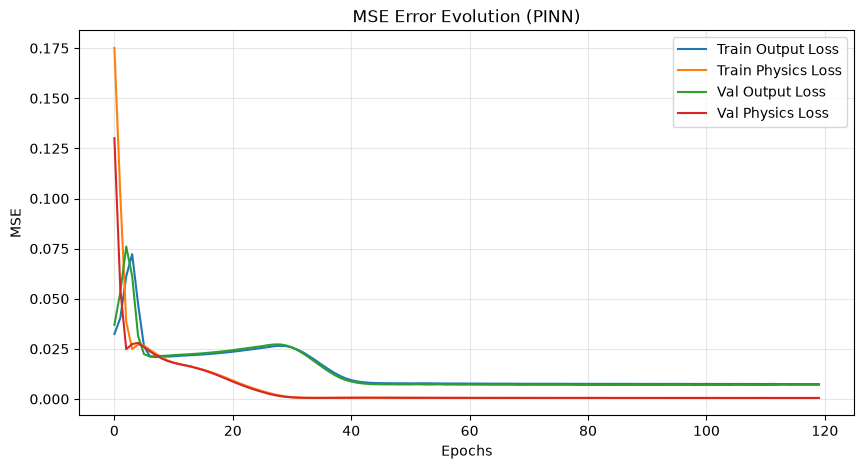

RMSE: 0.0841 | R²: 0.7415


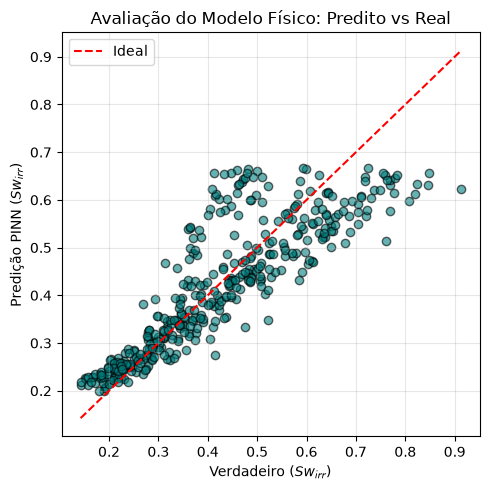

In [26]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARAÇÃO DOS DADOS
# ==========================================
# Assumindo train_df_augmented com 500 ecos + targets
X_data = train_df_augmented.iloc[:, :500].values
y_data = train_df_augmented['Swirr_PHIX'].values.reshape(-1, 1)

n = len(X_data)
n_train = int(0.8 * n)

indices = np.arange(n)
np.random.seed(42) 
np.random.shuffle(indices)

indx_train = indices[:n_train]
indx_val   = indices[n_train:]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(X_data).to(device)
y = torch.Tensor(y_data).to(device)

dataset = TensorDataset(X, y)
trainDs = Subset(dataset, indx_train)
valDs   = Subset(dataset, indx_val)

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

# ==========================================
# 2. DEFINIÇÃO DO MODELO PINN
# ==========================================
headlessmodel = nn.Sequential(
    nn.Linear(X.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 32),
    nn.ReLU(),
    nn.Linear(32, 4), # Saídas: A_o, A_w, ln(T2_o), ln(T2_w)
).to(device)

optimizer = torch.optim.Adam(headlessmodel.parameters(), lr=1e-3)

# [AJUSTE: Scheduler adicionado] Reduz a taxa de aprendizado se a validação parar de melhorar
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

# ==========================================
# 3. LOOP DE TREINAMENTO
# ==========================================
epochs = 120
history = []

for epoch in range(epochs):
    headlessmodel.train()
    train_loss_output, train_loss_phys = 0., 0.

    for xb, yb in train_loader:
        pre_outcome = headlessmodel(xb)
        
        # [AJUSTE: Amplitudes normalizadas e estabilizadas]
        outp1 = nn.Sigmoid()(pre_outcome[:,:2]) 
        
        # [AJUSTE: Log T2] A rede prevê livremente na saída. Deixamos os tensores como estão.
        outp2 = pre_outcome[:,2:] 
        
        outcome = torch.cat([outp1, outp2], dim=1)
        outcome_ext = outcome.unsqueeze(1).expand(*xb.shape, outcome.shape[-1])
        
        # [AJUSTE: Tempo Normalizado] Escala de 0 a 1 em vez de 0 a 500 para evitar underflow do gradiente
        t_idx = torch.arange(0, xb.shape[1], dtype=torch.float32).to(device)
        t_norm = (t_idx / xb.shape[1]).unsqueeze(0).expand(xb.shape)
        
        # Loss Output (Saturação) - Evita divisão por zero
        loss_output = nn.MSELoss()(outcome[:,0] / (outcome[:,0] + outcome[:,1] + 1e-8), yb.squeeze())
        
        # [AJUSTE: Reconstrução com Exponencial do T2]
        # Como o modelo previu log(T2), usamos torch.exp() para forçar positividade realística.
        T2_o = torch.exp(torch.clamp(outcome_ext[:,:,2], min=-10, max=5)) # Clamp evita instabilidade numérica extrema
        T2_w = torch.exp(torch.clamp(outcome_ext[:,:,3], min=-10, max=5))
        
        reconstrucao = (
            outcome_ext[:,:,0] * torch.exp(-t_norm / T2_o) + \
            outcome_ext[:,:,1] * torch.exp(-t_norm / T2_w)
        )
        loss_phys = nn.MSELoss()(xb, reconstrucao) 

        optimizer.zero_grad()
        (loss_output + 4 * loss_phys).backward() 
        optimizer.step()

        train_loss_output += loss_output.item() * xb.size(0)
        train_loss_phys += loss_phys.item() * xb.size(0)
        
    train_loss_output /= len(train_loader.dataset)
    train_loss_phys /= len(train_loader.dataset)

    # Avaliação
    headlessmodel.eval()
    val_loss_output, val_loss_phys = 0., 0.
    
    with torch.no_grad():
        for xb, yb in val_loader:
            pre_outcome = headlessmodel(xb)
            
            outp1 = nn.Sigmoid()(pre_outcome[:,:2])
            outp2 = pre_outcome[:,2:] # [AJUSTE: Mesmo fluxo do treino]
            
            outcome = torch.cat([outp1, outp2], dim=1)
            outcome_ext = outcome.unsqueeze(1).expand(*xb.shape, outcome.shape[-1])

            # [AJUSTE: Tempo Normalizado na validação]
            t_idx = torch.arange(0, xb.shape[1], dtype=torch.float32).to(device)
            t_norm = (t_idx / xb.shape[1]).unsqueeze(0).expand(xb.shape)
            
            loss_output = nn.MSELoss()(outcome[:,0] / (outcome[:,0] + outcome[:,1] + 1e-8), yb.squeeze())
            
            # [AJUSTE: Reconstrução com log T2 na validação]
            T2_o = torch.exp(torch.clamp(outcome_ext[:,:,2], min=-10, max=5))
            T2_w = torch.exp(torch.clamp(outcome_ext[:,:,3], min=-10, max=5))
            
            reconstrucao = (
                outcome_ext[:,:,0] * torch.exp(-t_norm / T2_o) + \
                outcome_ext[:,:,1] * torch.exp(-t_norm / T2_w)
            )
            loss_phys = nn.MSELoss()(xb, reconstrucao)
                                          
            val_loss_output += loss_output.item() * xb.size(0)
            val_loss_phys += loss_phys.item() * xb.size(0)
            
        val_loss_output /= len(val_loader.dataset)
        val_loss_phys /= len(val_loader.dataset)

    history.append((train_loss_output, train_loss_phys, val_loss_output, val_loss_phys))

    # [AJUSTE: Scheduler step avaliando o erro combinado]
    scheduler.step(val_loss_output + val_loss_phys)

    if (epoch + 1) % 10 == 0: 
        print(f"Epoch {epoch + 1:03d} | Train Out MSE: {train_loss_output:.4f} | Train Phys MSE: {train_loss_phys:.4f} "
              f"| Val Out MSE: {val_loss_output:.4f} | Val Phys MSE: {val_loss_phys:.4f}")

# ==========================================
# 4. GRÁFICOS DE TREINAMENTO
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(range(len(history)), [l[0] for l in history], label='Train Output Loss')
plt.plot(range(len(history)), [l[1] for l in history], label='Train Physics Loss')
plt.plot(range(len(history)), [l[2] for l in history], label='Val Output Loss')
plt.plot(range(len(history)), [l[3] for l in history], label='Val Physics Loss')
plt.title('MSE Error Evolution (PINN)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 5. AVALIAÇÃO FINAL
# ==========================================
Xval = valDs.dataset.tensors[0][valDs.indices]
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

headlessmodel.eval()
with torch.no_grad():
    pre_outcome_val = headlessmodel(Xval)
    outp1_val = nn.Sigmoid()(pre_outcome_val[:,:2])
    
    # [AJUSTE: A rede apenas expele os T2 sem softplus. Saturação depende apenas das amplitudes (outp1)]
    outp2_val = pre_outcome_val[:,2:]
    
    y_param_pred = torch.cat([outp1_val, outp2_val], dim=1).squeeze().detach().cpu().numpy()
 
# [AJUSTE: Margem de segurança na divisão (evitar NaN)]
y_predPINN = y_param_pred[:,0] / (y_param_pred[:,0] + y_param_pred[:,1] + 1e-8)

# Métricas: RMSE, R2
mse = np.mean((y_predPINN - yval)**2)
R2  = 1 - (mse / np.var(yval))
print(f"RMSE: {np.sqrt(mse):.4f} | R²: {R2:.4f}")

# Gráfico Predito vs Real Dinâmico
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_predPINN, alpha=0.6, color='teal', edgecolor='k')

# Reta ideal dinâmica
min_val = min(y_predPINN.min(), yval.min())
max_val = max(y_predPINN.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')

plt.ylabel("Predição PINN ($Sw_{irr}$)")
plt.xlabel("Verdadeiro ($Sw_{irr}$)")
plt.title("Avaliação do Modelo Físico: Predito vs Real")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Device is cpu
Epoch 010 | Train Out: 0.0078 | Train Phys: 0.0107 | Val Out: 0.0069 | Val Phys: 0.0100
Epoch 020 | Train Out: 0.0076 | Train Phys: 0.0037 | Val Out: 0.0070 | Val Phys: 0.0036
Epoch 030 | Train Out: 0.0073 | Train Phys: 0.0021 | Val Out: 0.0068 | Val Phys: 0.0021
Epoch 040 | Train Out: 0.0071 | Train Phys: 0.0015 | Val Out: 0.0068 | Val Phys: 0.0015
Epoch 050 | Train Out: 0.0073 | Train Phys: 0.0013 | Val Out: 0.0066 | Val Phys: 0.0010
Epoch 060 | Train Out: 0.0066 | Train Phys: 0.0008 | Val Out: 0.0065 | Val Phys: 0.0008
Epoch 070 | Train Out: 0.0064 | Train Phys: 0.0006 | Val Out: 0.0063 | Val Phys: 0.0006
Epoch 080 | Train Out: 0.0065 | Train Phys: 0.0006 | Val Out: 0.0065 | Val Phys: 0.0006
Epoch 090 | Train Out: 0.0059 | Train Phys: 0.0005 | Val Out: 0.0062 | Val Phys: 0.0005
Epoch 100 | Train Out: 0.0058 | Train Phys: 0.0005 | Val Out: 0.0060 | Val Phys: 0.0004
Epoch 110 | Train Out: 0.0057 | Train Phys: 0.0004 | Val Out: 0.0060 | Val Phys: 0.0004
Epoch 120 | Train 

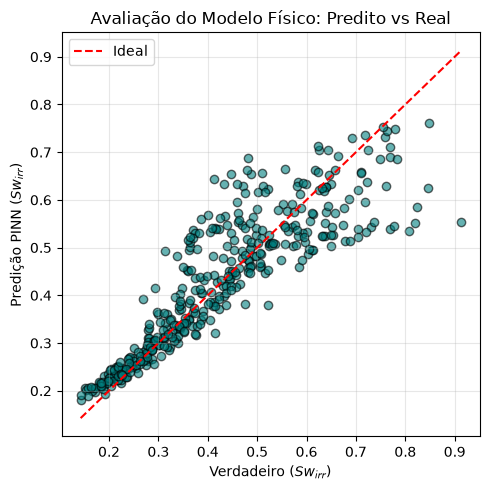

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

# ... [O código de preparação dos dados e DataLoader permanece idêntico] ...
X_data = train_df_augmented.iloc[:, :500].values
y_data = train_df_augmented['Swirr_PHIX'].values.reshape(-1, 1)

n = len(X_data)
n_train = int(0.8 * n)

indices = np.arange(n)
np.random.seed(42) 
np.random.shuffle(indices)

indx_train = indices[:n_train]
indx_val   = indices[n_train:]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(X_data).to(device)
y = torch.Tensor(y_data).to(device)

dataset = TensorDataset(X, y)
trainDs = Subset(dataset, indx_train)
valDs   = Subset(dataset, indx_val)

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)


# ==========================================
# 2. DEFINIÇÃO DO MODELO PINN
# ==========================================
headlessmodel = nn.Sequential(
    nn.Linear(X.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 32),
    nn.ReLU(),
    nn.Linear(32, 4), # Novas saídas: [Sw_bruto, M0_bruto, log(T2_curto), delta_log(T2)]
).to(device)

optimizer = torch.optim.Adam(headlessmodel.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

# ==========================================
# 3. LOOP DE TREINAMENTO (CORRIGIDO)
# ==========================================
epochs = 120
history = []

for epoch in range(epochs):
    headlessmodel.train()
    train_loss_output, train_loss_phys = 0., 0.

    for xb, yb in train_loader:
        pre_outcome = headlessmodel(xb)
        
        # 1. Swirr é previsto diretamente
        Sw_pred = nn.Sigmoid()(pre_outcome[:, 0]) 
        
        # 2. M0 (Amplitude Total)
        M0 = nn.functional.softplus(pre_outcome[:, 1]) 
        
        # 3. Tempos de Relaxação
        T2_curto = torch.exp(torch.clamp(pre_outcome[:, 2], min=-10, max=5))
        T2_longo = T2_curto + torch.exp(torch.clamp(pre_outcome[:, 3], min=-10, max=5))
        
        # Tempo normalizado
        t_idx = torch.arange(0, xb.shape[1], dtype=torch.float32).to(device)
        t_norm = (t_idx / xb.shape[1]).unsqueeze(0).expand(xb.shape)
        
        loss_output = nn.MSELoss()(Sw_pred, yb.squeeze())
        
        reconstrucao = M0.unsqueeze(1) * (
            Sw_pred.unsqueeze(1) * torch.exp(-t_norm / T2_curto.unsqueeze(1)) + \
            (1 - Sw_pred).unsqueeze(1) * torch.exp(-t_norm / T2_longo.unsqueeze(1))
        )
        
        # ==========================================
        # AS DUAS MÁGICAS (NO TREINO)
        # ==========================================
        pesos_tempo = torch.exp(-4.0 * t_norm).to(device) 
        erro_quadratico = (xb - reconstrucao) ** 2
        loss_phys = torch.mean(erro_quadratico * pesos_tempo) 

        optimizer.zero_grad()
        (20.0 * loss_output + 1.0 * loss_phys).backward() 
        optimizer.step()

        train_loss_output += loss_output.item() * xb.size(0)
        train_loss_phys += loss_phys.item() * xb.size(0)
        
    train_loss_output /= len(train_loader.dataset)
    train_loss_phys /= len(train_loader.dataset)

    # ================== AVALIAÇÃO ==================
    headlessmodel.eval()
    val_loss_output, val_loss_phys = 0., 0.
    
    with torch.no_grad():
        for xb, yb in val_loader:
            pre_outcome = headlessmodel(xb)
            
            Sw_pred = nn.Sigmoid()(pre_outcome[:, 0])
            M0 = nn.functional.softplus(pre_outcome[:, 1])
            T2_curto = torch.exp(torch.clamp(pre_outcome[:, 2], min=-10, max=5))
            T2_longo = T2_curto + torch.exp(torch.clamp(pre_outcome[:, 3], min=-10, max=5))

            t_idx = torch.arange(0, xb.shape[1], dtype=torch.float32).to(device)
            t_norm = (t_idx / xb.shape[1]).unsqueeze(0).expand(xb.shape)
        
            loss_output = nn.MSELoss()(Sw_pred, yb.squeeze())
        
            reconstrucao = M0.unsqueeze(1) * (
                Sw_pred.unsqueeze(1) * torch.exp(-t_norm / T2_curto.unsqueeze(1)) + \
                (1 - Sw_pred).unsqueeze(1) * torch.exp(-t_norm / T2_longo.unsqueeze(1))
            )
            
            # ==========================================
            # A MÁGICA DE PONDERAÇÃO (NA VALIDAÇÃO)
            # ==========================================
            pesos_tempo = torch.exp(-4.0 * t_norm).to(device) 
            erro_quadratico = (xb - reconstrucao) ** 2
            loss_phys = torch.mean(erro_quadratico * pesos_tempo) 
                                          
            val_loss_output += loss_output.item() * xb.size(0)
            val_loss_phys += loss_phys.item() * xb.size(0)
            
        val_loss_output /= len(val_loader.dataset)
        val_loss_phys /= len(val_loader.dataset)

    history.append((train_loss_output, train_loss_phys, val_loss_output, val_loss_phys))
    scheduler.step(val_loss_output + val_loss_phys)

    if (epoch + 1) % 10 == 0: 
        print(f"Epoch {epoch + 1:03d} | Train Out: {train_loss_output:.4f} | Train Phys: {train_loss_phys:.4f} "
              f"| Val Out: {val_loss_output:.4f} | Val Phys: {val_loss_phys:.4f}")
# ... [O código dos Gráficos permanece igual] ...

# ==========================================
# 5. AVALIAÇÃO FINAL (MÉTRICAS ATUALIZADAS)
# ==========================================
Xval = valDs.dataset.tensors[0][valDs.indices]
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

headlessmodel.eval()
with torch.no_grad():
    pre_outcome_val = headlessmodel(Xval)
    # A predição de Swirr agora é MUITO simples, basta passar pela Sigmoid no índice 0
    y_predPINN = nn.Sigmoid()(pre_outcome_val[:, 0]).squeeze().detach().cpu().numpy()
 
# Métricas: RMSE, R2
mse = np.mean((y_predPINN - yval)**2)
R2  = 1 - (mse / np.var(yval))
print(f"RMSE: {np.sqrt(mse):.4f} | R²: {R2:.4f}")

# Gráfico Predito vs Real Dinâmico
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_predPINN, alpha=0.6, color='teal', edgecolor='k')

# Reta ideal dinâmica
min_val = min(y_predPINN.min(), yval.min())
max_val = max(y_predPINN.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')

plt.ylabel("Predição PINN ($Sw_{irr}$)")
plt.xlabel("Verdadeiro ($Sw_{irr}$)")
plt.title("Avaliação do Modelo Físico: Predito vs Real")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()